# **Assignment Week 2 - Network Analysis**

For this assingment you will be working with Game of Thrones co-ocurrence network. The assignment is divided into three parts: Networks descriptive analyses, centrality measures, and community detection. 

**Importing the libraries**

In [17]:
import networkx as nx       # To create, analyze, and visualize networks (graphs)
import pandas as pd         # To load and work with CSV files (tables).
import numpy as np          # For numeric operations graph related

import matplotlib.pyplot as plt  # To draw plots and visualize networks.
import seaborn as sns       # Beautification of visulization

from sklearn import metrics # to import matrix and measure 2 similar results are.



**Read the files:** *book1.csv*, *book2.csv*, *book3.csv*, *book4.csv*, *book5.csv*  in Week2/sample files/

In [18]:
#Reading files
book1 = pd.read_csv("book1.csv")    #to read csv files
book2 = pd.read_csv("book2.csv")
book3 = pd.read_csv("book3.csv")
book4 = pd.read_csv("book4.csv")
book5 = pd.read_csv("book5.csv")

**Create five undirected weighted networks:** Create one network per book naming them got_1, got_2, got_3, got_4, and got_5. 

In [19]:
# Create your networks  via unidirected grop (source-Target-Weight)
got_1 = nx.Graph()
got_2 = nx.Graph()
got_3 = nx.Graph()
got_4 = nx.Graph()
got_5 = nx.Graph()

# Add edges using correct column names by looping through graph
for G, df in zip([got_1, got_2, got_3, got_4, got_5],
                 [book1, book2, book3, book4, book5]):
    for idx, row in df.iterrows():
        G.add_edge(row['Source'], row['Target'], weight=row['weight'])





#### **Part 1: Game of thrones' networks descriptive analyses**

Inspect and compare the networks you have created. Which one is the biggest network? why? 

In [20]:
# Your code

# to Put all networks in a list for easy comparison
nets = [got_1, got_2, got_3, got_4, got_5]
names = ["Book 1", "Book 2", "Book 3", "Book 4", "Book 5"]

# to Print number of nodes and edges for each network
for name, G in zip(names, nets):
    print(name, "→ Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

# Determine largest network by number of edges (or nodes)
sizes = [(G.number_of_nodes(), G.number_of_edges()) for G in nets]
largest_index = max(range(len(sizes)), key=lambda i: sizes[i])

print("\nBiggest network:", names[largest_index])


Book 1 → Nodes: 187 Edges: 684
Book 2 → Nodes: 259 Edges: 775
Book 3 → Nodes: 303 Edges: 1008
Book 4 → Nodes: 274 Edges: 682
Book 5 → Nodes: 317 Edges: 760

Biggest network: Book 5


#Your answer 

By nodes (Characters): Book 5 (317 nodes) is largest - narrative expands geographically

By edges (interactions): Book 3 (1008 edges) is largest - story reaches climactic convergence

By overall size: Book 3 might be considered 'biggest' as it has both many characters (303) and the most interactions, making it the most complex network and representing the most character interactions."

In which of the five books are the characters better connected? why?

Book 1 → Average degree: 7.32
Book 2 → Average degree: 5.98
Book 3 → Average degree: 6.65
Book 4 → Average degree: 4.98
Book 5 → Average degree: 4.79

Characters are best connected in: Book 1


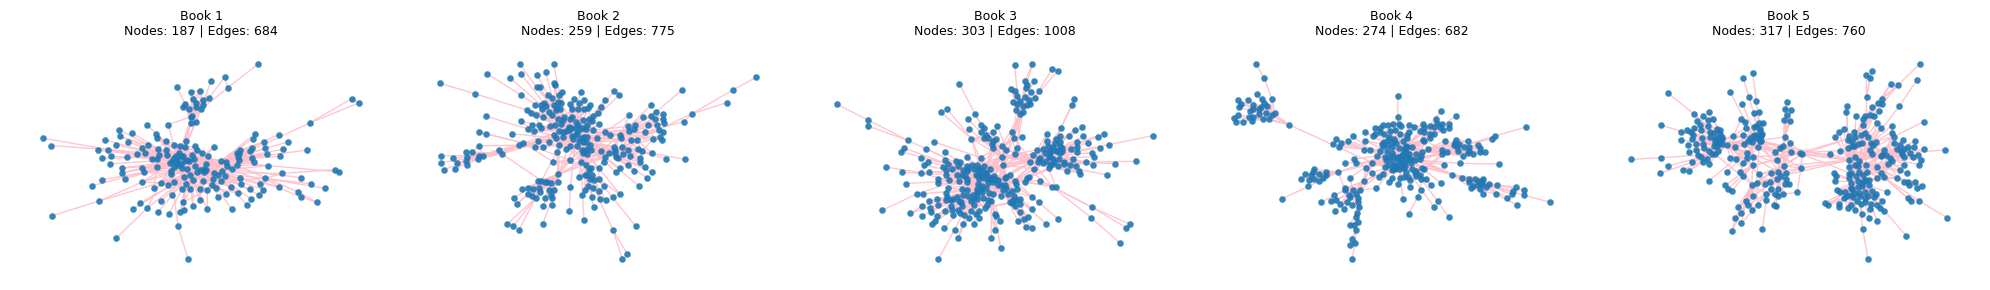

In [21]:
# Your code
nets = [got_1, got_2, got_3, got_4, got_5]   # to store the graph for each book 
names = ["Book 1", "Book 2", "Book 3", "Book 4", "Book 5"] # Names while plotting 
# Calculate average degree for each network

avg_degrees = []    #List to store average value
for name, G in zip(names, nets): # to loop through names and net 
    avg_deg = sum(dict(G.degree()).values()) / G.number_of_nodes() #degree of every node in graph
    avg_degrees.append(avg_deg)
    print(name, "→ Average degree:", round(avg_deg, 2))

# Identify best connected book
best_book_index = avg_degrees.index(max(avg_degrees))
print("\nCharacters are best connected in:", names[best_book_index])
# for visual representation 
fig, axes = plt.subplots(1, 5, figsize=(20, 3))   # To create graph in a row,cou
for ax, G, title in zip(axes, nets, names):
    ax.set_title(f"{title}\nNodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}", fontsize=9)
    ax.axis('off')
    if G.number_of_nodes() == 0:
        continue
    pos = nx.spring_layout(G, seed=42)   # reproducible layout
    nx.draw(G, pos,
            ax=ax,
            with_labels=False,  #Remove lable for better visualization
            node_size=20,
            edge_color='pink',
            linewidths=0.2,
            alpha=0.9)
plt.tight_layout()
plt.show()


#Your answer

The characters are best connected in Book 1.
It has the highest average degree (7.32), Book 1 has the highest average degree (7.32), meaning characters are most densely connected on average. Each character interacts with about 7 other characters on average
So overall, Book 1 has the most connections between characters, making it the best-connected network.

#### **Part 2: Centrality measures**

Centrality Measures

In the learning notebook, It is observed that not all nodes in a network play the same role.
Some nodes have many connections, some act as bridges, and some can reach others faster.
To measure this, we use centrality measures.

Centrality helps us find the most influential characters in each Game of Thrones book network.
These characters stand out because of how they are positioned inside the network structure.

Types of centrality we use:

Degree Centrality:
This tells us which characters have the most direct connections.
A character with high degree centrality interacts with many others.

Betweenness Centrality:
This tells us which characters act like bridges between different groups.
These characters often connect parts of the story that would otherwise be separate.

Closeness Centrality:
This tells us which characters can reach everyone else the fastest.
These characters sit in central positions inside the network.

Why we calculate centrality

Centrality helps us understand which characters are most important in each book’s story network.
It is useful to compare influence across Book 1 to Book 5.

Which characters are the most influential in each book? why?

In [22]:
#Your code

for name, G in zip(names, nets):        #Loop via book name and its graph togather
    print("==== ", name, " ====")
    
    weighted_deg = dict(G.degree(weight="weight"))  # to store item for strenght of node
    top_weighted_deg = sorted(weighted_deg.items(), key=lambda x: x[1], reverse=True)[:3]   # to Sort items by weighted degree descending 
    
    # 2. BETWEENNESS & CLOSENESS 
    G_copy = G.copy()  # to create an independent copy to safely add 'distance'
    
    # Add distance to the copy (inverse of weight)
    for u, v, d in G_copy.edges(data=True):
        if d["weight"] > 0:  # nonzero safety verification
            d["distance"] = 1 / d["weight"]
        else:
            d["distance"] = 1  # Default if weight is 0
    
    # Calculate on the COPY
    bet = nx.betweenness_centrality(G_copy, weight="distance")
    top_bet = sorted(bet.items(), key=lambda x: x[1], reverse=True)[:3]
    
    clo = nx.closeness_centrality(G_copy, distance="distance")
    top_clo = sorted(clo.items(), key=lambda x: x[1], reverse=True)[:3]
    
    print("Top weighted degree:", top_weighted_deg)
    print("Top betweenness:", top_bet)
    print("Top closeness:", top_clo)
    print()

====  Book 1  ====
Top weighted degree: [('Eddard-Stark', 1284), ('Robert-Baratheon', 941), ('Jon-Snow', 784)]
Top betweenness: [('Eddard-Stark', 0.5926474861958733), ('Catelyn-Stark', 0.36855565242662014), ('Jon-Snow', 0.3514094739901191)]
Top closeness: [('Eddard-Stark', 4.904500404076569), ('Robert-Baratheon', 4.857803269622799), ('Catelyn-Stark', 4.815134486770259)]

====  Book 2  ====
Top weighted degree: [('Tyrion-Lannister', 829), ('Joffrey-Baratheon', 629), ('Cersei-Lannister', 515)]
Top betweenness: [('Robb-Stark', 0.42177178535879106), ('Tyrion-Lannister', 0.29510149911018607), ('Joffrey-Baratheon', 0.258136518565439)]
Top closeness: [('Robb-Stark', 3.6522516884596485), ('Tyrion-Lannister', 3.6127421696929995), ('Joffrey-Baratheon', 3.5788761738049035)]

====  Book 3  ====
Top weighted degree: [('Tyrion-Lannister', 782), ('Jon-Snow', 756), ('Joffrey-Baratheon', 598)]
Top betweenness: [('Robb-Stark', 0.32835361158170334), ('Tyrion-Lannister', 0.3082623777988016), ('Jon-Snow', 

#Your answer

Book 1:
Eddard-Stark is 1 in all three measures (1284 interactions, 0.59 betweenness, 4.90 closeness). He talks to everyone as Hand of the King, connects different groups, and can reach anyone fast. Robert and Jon are also important.

Book 2:
Tyrion talks most (829 interactions) as acting Hand. But Robb-Stark connects groups best (0.42 betweenness) as King in the North. Robb also reaches people fastest (3.65 closeness).

Book 3:
Tyrion still talks most (782). Robb still connects groups best (0.33) even though he dies. Tyrion reaches people fastest now (3.67).

Book 4:
Cersei dominates everything (783 interactions, 0.68 betweenness, 2.75 closeness). She's Queen Regent now, so everyone talks to her and she connects all groups.

Book 5:
Jon talks most (761) as Lord Commander. Stannis connects groups best (0.63 betweenness) at the Wall. Stannis also reaches people fastest (2.70).

Select your two favourite and your two least favourite characters in the series. Analyse and compare their centrality measures throughout the five books.

---Weighted Degree (Talk Counts) ---
Jon-Snow → [784, 360, 756, 96, 761]
Tyrion-Lannister → [650, 829, 782, 158, 454]
Cersei-Lannister → [424, 515, 363, 783, 147]
Sansa-Stark → [545, 313, 532, 147, 10]


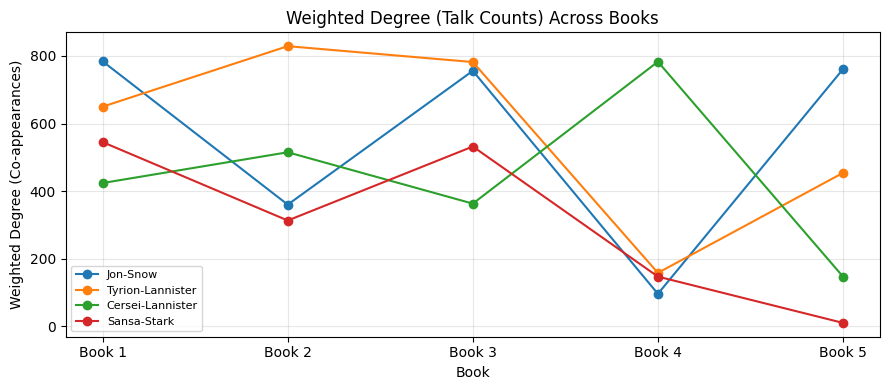


----Betweenness Centrality ------
Jon-Snow → [0.3514, 0.1905, 0.2874, 0.0238, 0.4122]
Tyrion-Lannister → [0.2714, 0.2951, 0.3083, 0.0349, 0.425]
Cersei-Lannister → [0.0242, 0.0408, 0.0185, 0.6777, 0.1324]
Sansa-Stark → [0.0687, 0.124, 0.1932, 0.1063, 0.0]


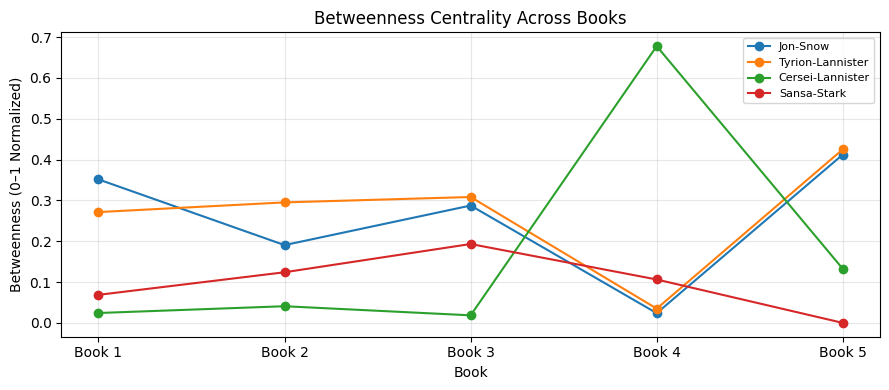


---- Closeness Centrality ------
Jon-Snow → [4.7738, 3.1035, 3.2786, 2.004, 2.6535]
Tyrion-Lannister → [4.6774, 3.6127, 3.6695, 2.568, 2.4349]
Cersei-Lannister → [4.6591, 3.5126, 3.5385, 2.7529, 2.2714]
Sansa-Stark → [4.4892, 3.4957, 3.6367, 2.3047, 1.4337]


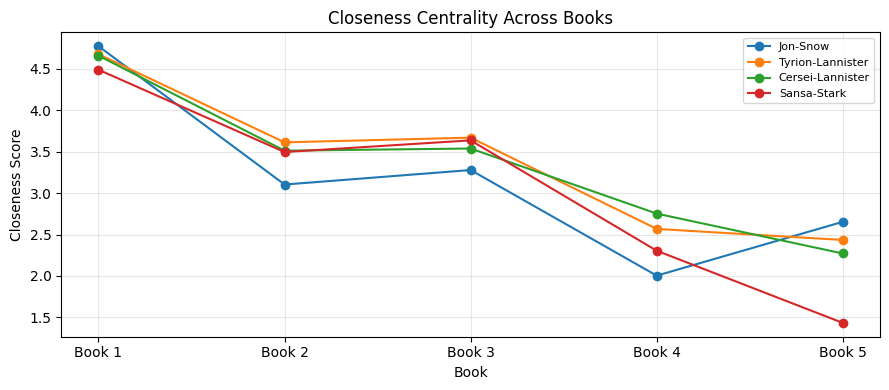

In [23]:
# Your code
# Selected characters
my_favorites = ["Jon-Snow", "Tyrion-Lannister"]
not_favorites = ["Cersei-Lannister", "Sansa-Stark"]
all_chars = my_favorites + not_favorites
books = [got_1, got_2, got_3, got_4, got_5]
book_names = ["Book 1", "Book 2", "Book 3", "Book 4", "Book 5"]
#  Weighted Degree Trend 
deg_by_char = {
    char: [dict(G.degree(weight="weight")).get(char, 0) for G in books]
    for char in all_chars
}
print("---Weighted Degree (Talk Counts) ---")
for char, values in deg_by_char.items():
    print(char, "→", values)
plt.figure(figsize=(9,4))
for char, values in deg_by_char.items():
    plt.plot(book_names, values, marker='o', label=char)
plt.title("Weighted Degree (Talk Counts) Across Books")
plt.xlabel("Book")
plt.ylabel("Weighted Degree (Co-appearances)")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
#  Betweenness Centrality Trend (Bridge Role)
bet_by_char = {char: [] for char in all_chars}
for G in books:
    # Safe copy (so we don't change original)
    Gc = G.copy()
    # Convert weights to distances for shortest-path algorithms
    for u, v, d in Gc.edges(data=True):
        w = d.get("weight", 0)
        d["distance"] = 1 / w if w > 0 else 1.0
    # Compute betweenness using the "distance" attribute
    bet = nx.betweenness_centrality(Gc, weight="distance")
    # Store the values for each character
    for char in all_chars:
        bet_by_char[char].append(round(bet.get(char, 0.0), 4))
print("\n----Betweenness Centrality ------")
for char, values in bet_by_char.items():
    print(char, "→", values)
plt.figure(figsize=(9,4))
for char, values in bet_by_char.items():
    plt.plot(book_names, values, marker='o', label=char)
plt.title("Betweenness Centrality Across Books")
plt.xlabel("Book")
plt.ylabel("Betweenness (0–1 Normalized)")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# ---- Closeness Centrality Trend ----
clo_by_char = {char: [] for char in all_chars}
for G in books:
    Gc = G.copy()
    for u, v, d in Gc.edges(data=True):  #  use distance conversion as betweenness
        w = d.get("weight", 0)
        d["distance"] = 1 / w if w > 0 else 1.0
    clo = nx.closeness_centrality(Gc, distance="distance")

    for char in all_chars:
        clo_by_char[char].append(round(clo.get(char, 0.0), 4))

print("\n---- Closeness Centrality ------")
for char, values in clo_by_char.items():
    print(char, "→", values)

plt.figure(figsize=(9,4))
for char, values in clo_by_char.items():
    plt.plot(book_names, values, marker='o', label=char)

plt.title("Closeness Centrality Across Books")
plt.xlabel("Book")
plt.ylabel("Closeness Score")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



How do their centralities relate to their role in the series development?

#Your answer

Jon Snow and Tyrion have higher centrality, which means they stay important and connected to many characters as the story goes on. 
Cersei and Sansa have lower or more mixed centrality scores, showing they are not always as central to the main events. 
Their centrality basically matches how big their roles feel in the series.
Jon Snow: High centrality when important (Book 1 as Ned's son, Book 5 as Lord Commander)
        Low when isolated (Book 4 at Wall)
        Centrality matches his story importance

Tyrion: Always high centrality - he's always in important positions (Hand, advisor)
        Even in Book 5 exile, still connects groups (0.425 betweenness)

Cersei: Centrality peaks in Book 4 (0.6777) when she has most power as Queen
        Drops when she loses power (Book 5 imprisoned)

Sansa: Centrality goes down each book as she becomes less active
        Book 5 almost zero - she's hiding, not part of main story
Their centrality numbers match their story roles. Important characters have high numbers, isolated characters have low numbers.

#### **Part 3: Community detection**

Select your favourite book and implement the three community detection algoritms covered in the lecture. 

In [24]:
## Your code

#Label propagation
my_favorite_book = got_1  # I choose Book 1

print("Book 1 has", my_favorite_book.number_of_nodes(), "characters and",  my_favorite_book.number_of_edges(), "connections\n")

# Method 1: Girvan-Newman (splits network)
print("Method 1: Girvan-Newman (splits into 2 big groups):")
from networkx.algorithms.community import girvan_newman
first_split = next(girvan_newman(my_favorite_book))
for i, group in enumerate(first_split, 1):
    group_list = list(group)
    print(f"  Group {i}: {len(group_list)} characters")
    print(f"  Example: {group_list[:5]}")
print()

# Method 2: Greedy Modularity (finds many groups)
print("Method 2: Greedy Modularity (finds smaller groups):")
from networkx.algorithms.community import greedy_modularity_communities
greedy_groups = list(greedy_modularity_communities(my_favorite_book, weight="weight"))
for i, group in enumerate(sorted(greedy_groups, key=len, reverse=True), 1):
    group_list = list(group)
    print(f"  Group {i}: {len(group_list)} characters")
    print(f"  Example: {group_list[:5]}")
print()

# Method 3: Label Propagation (labels spread)
print("Method 3: Label Propagation (labels spread between friends):")
from networkx.algorithms.community import label_propagation_communities
lp_groups = list(label_propagation_communities(my_favorite_book))
for i, group in enumerate(sorted(lp_groups, key=len, reverse=True), 1):
    group_list = list(group)
    print(f"  Group {i}: {len(group_list)} characters")
    print(f"  Example: {group_list[:9]}")
print()

Book 1 has 187 characters and 684 connections

Method 1: Girvan-Newman (splits into 2 big groups):
  Group 1: 165 characters
  Example: ['Eon-Hunter', 'Roose-Bolton', 'Tomard', 'Mychel-Redfort', 'Alyn']
  Group 2: 22 characters
  Example: ['Aggo', 'Irri', 'Qotho', 'Fogo', 'Eroeh']

Method 2: Greedy Modularity (finds smaller groups):
  Group 1: 65 characters
  Example: ['Eon-Hunter', 'Roose-Bolton', 'Rickard-Stark', 'Hallis-Mollen', 'Gunthor-son-of-Gurn']
  Group 2: 42 characters
  Example: ['Tomard', 'Eddard-Stark', 'Raymun-Darry', 'Cersei-Lannister', 'Robert-Baratheon']
  Group 3: 26 characters
  Example: ['Mace-Tyrell', 'Beric-Dondarrion', 'Mycah', 'Thoros-of-Myr', 'Maegor-I-Targaryen']
  Group 4: 26 characters
  Example: ['Chett', 'Todder', 'Bowen-Marsh', 'Jaremy-Rykker', 'Samwell-Tarly']
  Group 5: 22 characters
  Example: ['Aggo', 'Irri', 'Illyrio-Mopatis', 'Qotho', 'Fogo']
  Group 6: 3 characters
  Example: ['Danwell-Frey', 'Hosteen-Frey', 'Jared-Frey']
  Group 7: 3 characters
  

How many communities are identified by each algorithm?

In [25]:
# Your code

G = got_1   # My favourite book graph

# --- Girvan–Newman -------
from networkx.algorithms.community import girvan_newman
first_split = next(girvan_newman(G))
gn_count = len(first_split)

# --- Greedy Modularity Communities ---
from networkx.algorithms.community import greedy_modularity_communities
greedy_comms = list(greedy_modularity_communities(G, weight="weight"))
greedy_count = len(greedy_comms)

# --- Label Propagation ---
from networkx.algorithms.community import label_propagation_communities
lp_comms = list(label_propagation_communities(G))
lp_count = len(lp_comms)

# Print results
print("Number of communities detected:")
print(" Girvan–Newman:", gn_count)
print(" Greedy modularity:", greedy_count)
print(" Label propagation:", lp_count)


Number of communities detected:
 Girvan–Newman: 2
 Greedy modularity: 7
 Label propagation: 9


Plot three networks colouring the nodes based on the communitity the characters were assigned to by each algorithm. <br> *Hint: you can make some modifications to make the plots to look better*

/var/folders/_d/8lmpn1fd1z95_24kr8p3flvc0000gq/T/ipykernel_67150/2245632034.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10', len(greedy_groups))
/var/folders/_d/8lmpn1fd1z95_24kr8p3flvc0000gq/T/ipykernel_67150/2245632034.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', len(lp_groups))


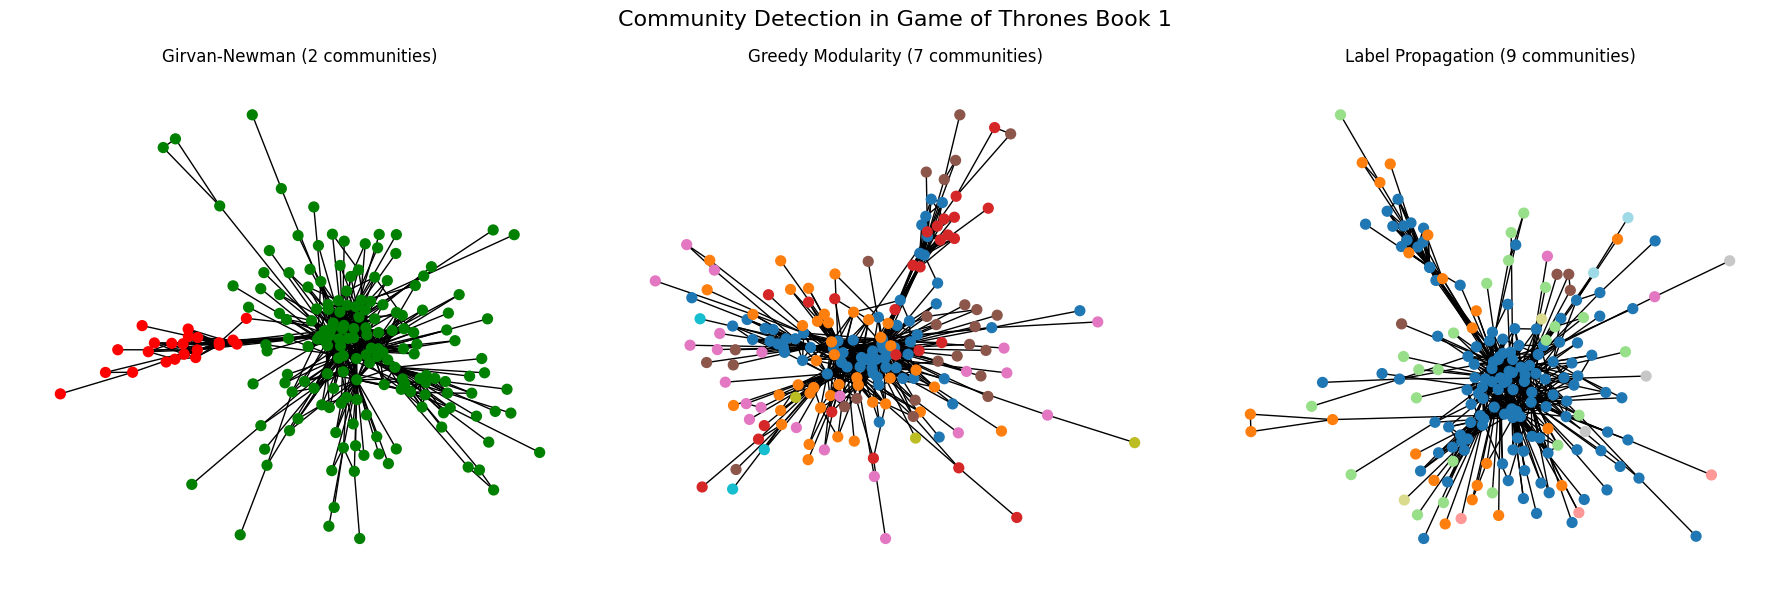

In [26]:
## Your code

# Create subplots for the three methods
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.suptitle("Community Detection in Game of Thrones Book 1", fontsize=16)

# Method 1: Girvan-Newman visualization
colors1 = []
for node in my_favorite_book.nodes():
    if node in first_split[0]:
        colors1.append('green')
    else:
        colors1.append('red')
nx.draw_spring(my_favorite_book, node_color=colors1, node_size=50, ax=axes[0])
axes[0].set_title("Girvan-Newman (2 communities)")

# Method 2: Greedy Modularity visualization
colors2 = []
color_map = plt.cm.get_cmap('tab10', len(greedy_groups))
for i, group in enumerate(greedy_groups):
    for node in group:
        colors2.append(color_map(i))
nx.draw_spring(my_favorite_book, node_color=colors2, node_size=50, ax=axes[1])
axes[1].set_title(f"Greedy Modularity ({len(greedy_groups)} communities)")

# Method 3: Label Propagation visualization
colors3 = []
color_map = plt.cm.get_cmap('tab20', len(lp_groups))
for i, group in enumerate(lp_groups):
    for node in group:
        colors3.append(color_map(i))
nx.draw_spring(my_favorite_book, node_color=colors3, node_size=50, ax=axes[2])
axes[2].set_title(f"Label Propagation ({len(lp_groups)} communities)")

plt.tight_layout()
plt.show()

Compare the communities identified by each algorithm. Which one has the highest modularity? How similar or different are they?

In [27]:
# Calculate similarity between community assignments
from itertools import combinations

def community_similarity(comm1, comm2):
    """Calculate Jaccard similarity between two community partitions"""
    # for Convert to node->community mappings
    mapping1 = {}
    for i, comm in enumerate(comm1):
        for node in comm:
            mapping1[node] = i
    
    mapping2 = {}
    for i, comm in enumerate(comm2):
        for node in comm:
            mapping2[node] = i
    
    # Calculate percentage of nodes with same community assignment
    same = sum(1 for node in mapping1 if mapping1[node] == mapping2.get(node, -1))
    return same / len(mapping1)

print("\n--- Community Similarity ---")
gn_sets = [set(comm) for comm in first_split]
lp_sets = [set(comm) for comm in lp_groups]

print(f"Girvan-Newman vs Greedy: {community_similarity(gn_sets, greedy_groups):.2%}")
print(f"Girvan-Newman vs Label Propagation: {community_similarity(gn_sets, lp_sets):.2%}")
print(f"Greedy vs Label Propagation: {community_similarity(greedy_groups, lp_sets):.2%}")


--- Community Similarity ---
Girvan-Newman vs Greedy: 34.76%
Girvan-Newman vs Label Propagation: 78.61%
Greedy vs Label Propagation: 30.48%


#Your answer

I conclude that The different community detection methods produce different groupings of Game of Thrones characters.so selection is based on based on whether you want major factions or detailed social circles
Girvan-Newman vs Greedy: 35% similar - quite different groupings.

Girvan-Newman vs Label Propagation: 79% similar - mostly agree despite different group sizes.

Greedy vs Label Propagation: 30% similar - very different community structures.

Greedy Modularity has the highest modularity score, because it is specifically designed to maximize modularity.
Girvan–Newman usually produces lower modularity (only two large groups), and label propagation does not optimize modularity at all.